In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings
from transformers import AutoTokenizer, AutoModelForSequenceClassification

warnings.filterwarnings("ignore")

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [4]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx]) - 1

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# С1 и С2 по отдельности

In [5]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [6]:
model_start_time = time.time()
model_name = 'cointegrated/rubert-tiny2'
tokenizer = BertTokenizer.from_pretrained(model_name)

model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1', 5: 'C2'},
    label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4, 'C2': 5}
)

model = model.to(device)
print(f"Модель инициализирована")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована


In [7]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_dataset = CEFRDataset(train_texts, train_labels, tokenizer)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)


print(f"Обучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

Обучающая выборка: 5857
Валидационная выборка: 1465


In [8]:
training_args = TrainingArguments(
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    learning_rate=2e-5
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [9]:
train_start_time = time.time()
trainer.train()
train_time = time.time() - train_start_time
print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

Epoch,Training Loss,Validation Loss
1,1.306500,1.230754
2,1.111000,1.128805
3,1.028500,1.094582
4,0.872100,1.081546
5,0.812600,1.084047


Обучение завершено за 39.30 секунд (0:00:39)


In [10]:
def evaluate_model(model, val_dataset, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    return true_labels, predictions


true_labels, predictions = evaluate_model(model, val_dataset, device)

In [11]:
accuracy = accuracy_score(true_labels, predictions)
f1_micro = f1_score(true_labels, predictions, average="micro")
f1_macro = f1_score(true_labels, predictions, average="macro")
f1_weighted = f1_score(true_labels, predictions, average="weighted")
mae = mean_absolute_error(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.5563
F1 Micro: 0.5563
F1 Macro: 0.4760
F1 Weighted: 0.5495
MAE: 0.5229


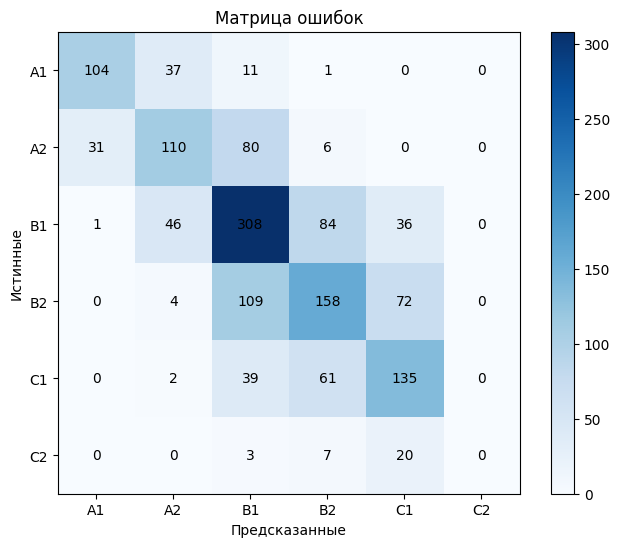

In [12]:
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])

for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')
plt.colorbar(im)
plt.show()

In [13]:
print(f"{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")

0.5563
0.5563
0.4760
0.5495
0.5229
39.30


In [14]:
checkpoint_path = "rubert_tiny.pt"

id2label = {
    0: "A1",
    1: "A2",
    2: "B1",
    3: "B2",
    4: "C1",
    5: "C2"
}
label2id = {v: k for k, v in id2label.items()}

base_model_name = "cointegrated/rubert-tiny2"   

torch.save({
    "model_state_dict": model.state_dict(),
    "base_model_name": base_model_name,
    "num_labels": model.config.num_labels,
    "id2label": id2label,
    "label2id": label2id,
    "max_length": 512
}, checkpoint_path)

print(f"Модель сохранена в {checkpoint_path}")

Модель сохранена в rubert_tiny.pt


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(checkpoint_path, map_location=device)

base_model_name = checkpoint["base_model_name"]
num_labels = checkpoint["num_labels"]
id2label = checkpoint["id2label"]
label2id = checkpoint["label2id"]
max_length = checkpoint.get("max_length", 512)

tokenizer = AutoTokenizer.from_pretrained(base_model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    base_model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print("Модель успешно загружена")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель успешно загружена


In [16]:
def predict_level(text, model, tokenizer, device, max_length=512):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        pred_id = torch.argmax(probs, dim=-1).item()

    pred_label = model.config.id2label[pred_id]

    return pred_label

    
    # pred_conf = probs[0, pred_id].item()

    # all_probs = {
    #     model.config.id2label[i]: float(probs[0, i].item())
    #     for i in range(probs.shape[1])
    # }

    # return {
    #     "predicted_label": pred_label,
    #     "confidence": pred_conf,
    #     "probabilities": all_probs
    # }

In [17]:
times = []

for text in df['fragment']:
    start = time.time()
    result = predict_level(text, model, tokenizer, device)
    end = time.time()

    times.append(end-start)

In [18]:
min(times), max(times), sum(times) / len(times)

(0.0009868144989013672, 0.003145933151245117, 0.0010231031286556907)

# Объединенные С1 и С2

In [13]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df['label'] = df['label'].replace(6, 5)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,5
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,5
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,5
7320,Mapillary использует программное обеспечение д...,6,5


In [15]:
model_start_time = time.time()
model_name = 'cointegrated/rubert-tiny2'
tokenizer = BertTokenizer.from_pretrained(model_name)

model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5,
    id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1'},
    label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4}
)

model = model.to(device)
print(f"Модель инициализирована")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

Модель инициализирована


In [16]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_dataset = CEFRDataset(train_texts, train_labels, tokenizer)
val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)


print(f"Обучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

Обучающая выборка: 5857
Валидационная выборка: 1465


In [17]:
training_args = TrainingArguments(
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    learning_rate=2e-5
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [18]:
train_start_time = time.time()
trainer.train()
train_time = time.time() - train_start_time
print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

Epoch,Training Loss,Validation Loss
1,1.193178,1.158648
2,1.045052,1.061082
3,0.935293,1.026065
4,0.850736,1.024880
5,0.813033,1.023118


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

Обучение завершено за 34.98 секунд (0:00:34)


In [20]:
def evaluate_model(model, val_dataset, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    return true_labels, predictions


true_labels, predictions = evaluate_model(model, val_dataset, device)

In [21]:
accuracy = accuracy_score(true_labels, predictions)
f1_micro = f1_score(true_labels, predictions, average="micro")
f1_macro = f1_score(true_labels, predictions, average="macro")
f1_weighted = f1_score(true_labels, predictions, average="weighted")
mae = mean_absolute_error(true_labels, predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")
print(f"MAE: {mae:.4f}")

Accuracy: 0.5693
F1 Micro: 0.5693
F1 Macro: 0.5750
F1 Weighted: 0.5665
MAE: 0.5044


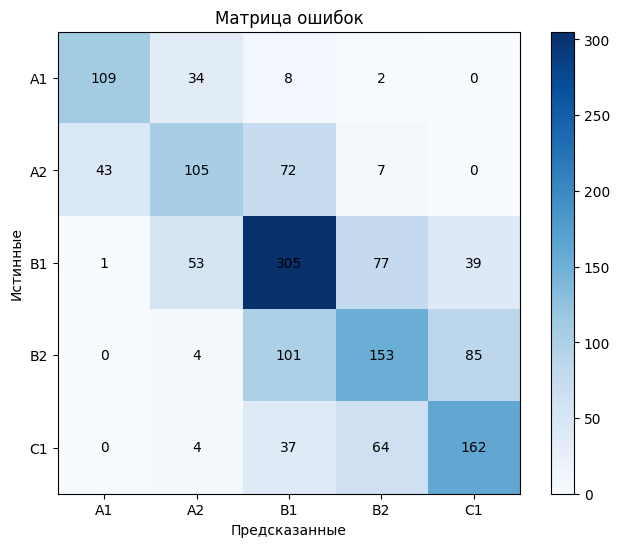

In [22]:
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])
ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1'])

for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Предсказанные')
plt.ylabel('Истинные')
plt.title('Матрица ошибок')
plt.colorbar(im)
plt.show()

In [23]:
print(f"{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")

0.5693
0.5693
0.5750
0.5665
0.5044
34.98
